In [228]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [229]:
X_train = pd.read_csv("X_wo_train.csv")
X_test = pd.read_csv("X_wo_test.csv")

y_train = pd.read_csv("y_wo_train.csv")
y_test = pd.read_csv("y_wo_test.csv")

In [230]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [231]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (274676, 14)
X_test : (68719, 14)
y_train: (274676,)
y_test : (68719,)


In [ ]:
#Target encoding di model e manufacturer
target_cols = [
    "manufacturer",
    "model"
]

''' sostiuisce con il prezzo medio per marca ed il prezzo medio per modello i valori stringa'''


global_mean = y_train.mean()

for col in target_cols:

    train_col = X_train[col].fillna("missing")
    test_col = X_test[col].fillna("missing")

    target_mean = y_train.groupby(train_col).mean()

    X_train[col] = (
        train_col
        .map(target_mean)
        .fillna(global_mean)
    )

    X_test[col] = (
        test_col
        .map(target_mean)
        .fillna(global_mean)
    )

In [ ]:
onehot_cols = [
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "size",
    "type",
    "paint_color",
    "state"
]

#one hot encoding delle feature categoriche con cardinalità non troppo elevata
X_train = pd.get_dummies(
    X_train,
    columns=onehot_cols,
    dummy_na=True
)

X_test = pd.get_dummies(
    X_test,
    columns=onehot_cols,
    dummy_na=True
)

In [234]:
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [235]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
#eliminazione dei valori che non rientrano nel range di prezzi

mask_train = y_train.between(500,80000)

X_train = X_train.loc[mask_train]
y_train = y_train.loc[mask_train]
mask_test = y_test.between(500, 80000)

X_test = X_test.loc[mask_test]
y_test = y_test.loc[mask_test]

In [ ]:
from datetime import datetime
current_year = datetime.now().year

#creazione della feature età dell'auto

X_train["car_age"] = current_year - X_train["year"]
X_test["car_age"] = current_year - X_test["year"]

In [238]:
model = XGBRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [239]:
model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [240]:
y_pred = model.predict(X_test)

In [241]:
mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"RMSE: {rmse:,.2f}")
print(f"MAE : {mae:,.2f}")
print(f"R²  : {r2:.4f}")
# Analisi errori


RMSE: 3,860.29
MAE : 2,259.44
R²  : 0.9127


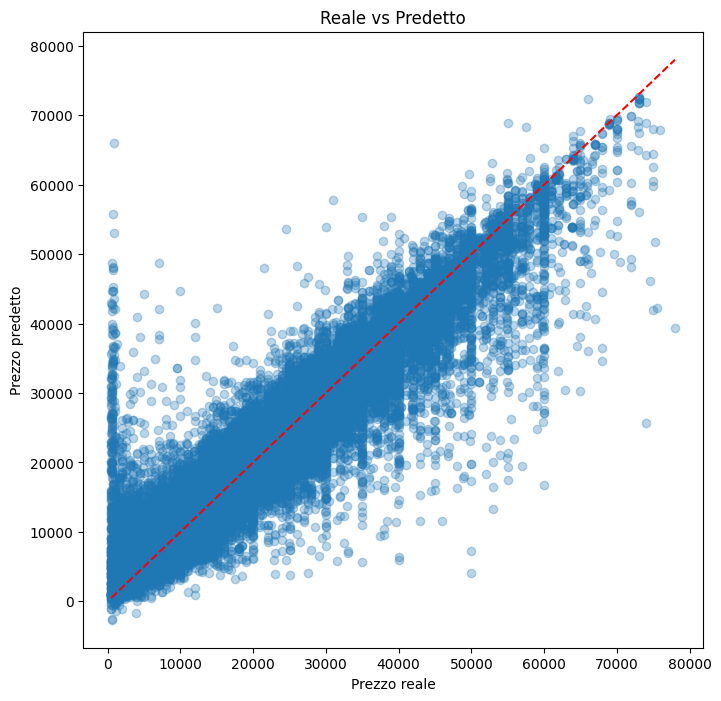

In [242]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Prezzo reale")
plt.ylabel("Prezzo predetto")
plt.title("Reale vs Predetto")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.show()

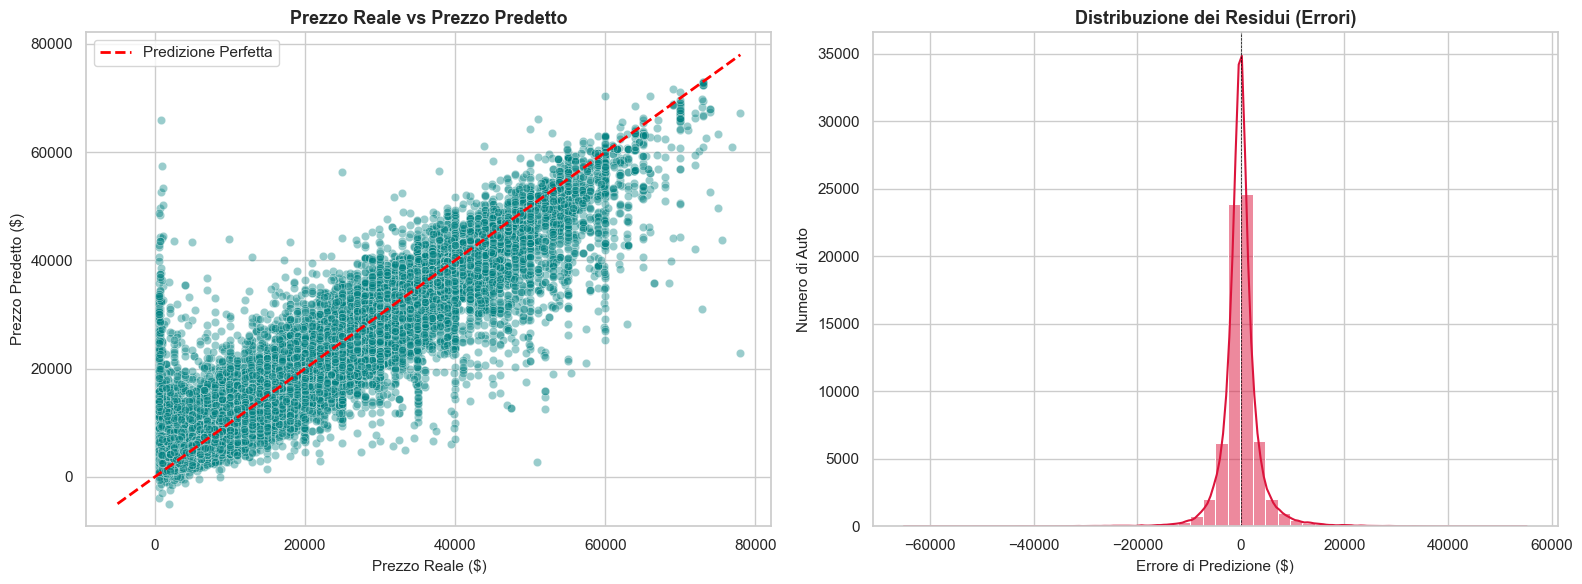


🔍 I 5 ERRORI PIÙ GRAVI DEL MODELLO (SOTTOSTIME O SOVRASTIME EPICHE):
       Reale      Predetto  Errore_Assoluto
51401    830  65943.039062     65113.039062
61408    917  57391.246094     56474.246094
14107  78000  22819.236328     55180.763672
50441   1030  53473.707031     52443.707031
44000    833  52707.410156     51874.410156


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# DIAGNOSTICA DEGLI ERRORI
# 1. Calcoliamo i residui sul set di test
residui = y_test - y_pred

# Creiamo una figura con due grafici affiancati (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------------------
# GRAFICO A: Prezzo Reale vs Prezzo Predetto
# -------------------------------------------------------------------------
sns.scatterplot(ax=axes[0], x=y_test, y=y_pred, alpha=0.4, color='teal')

# Disegniamo la linea di "predizione perfetta" a 45 gradi
limiti = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limiti, limiti, color='red', linestyle='--', linewidth=2, label='Predizione Perfetta')

axes[0].set_title("Prezzo Reale vs Prezzo Predetto", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Prezzo Reale ($)", fontsize=11)
axes[0].set_ylabel("Prezzo Predetto ($)", fontsize=11)
axes[0].legend()

# -------------------------------------------------------------------------
# GRAFICO B: Distribuzione degli Errori (Residui)
# -------------------------------------------------------------------------
sns.histplot(ax=axes[1], x=residui, kde=True, color='crimson', bins=50)

# Disegniamo la linea sullo zero (errore nullo)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.5)

axes[1].set_title("Distribuzione dei Residui (Errori)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Errore di Predizione ($)", fontsize=11)
axes[1].set_ylabel("Numero di Auto", fontsize=11)

plt.tight_layout()
plt.show()


# =========================================================================
# ANALISI EXTRA: DOVE SBAGLIA DI PIÙ?
# =========================================================================
# Creiamo un piccolo DataFrame per isolare i casi peggiori
analisi_errori = pd.DataFrame({
    'Reale': y_test,
    'Predetto': y_pred,
    'Errore_Assoluto': np.abs(residui)
}).sort_values(by='Errore_Assoluto', ascending=False)

print("\n=========================================================================")
print("🔍 I 5 ERRORI PIÙ GRAVI DEL MODELLO (SOTTOSTIME O SOVRASTIME EPICHE):")
print("=========================================================================")
print(analisi_errori.head())
print("=========================================================================")

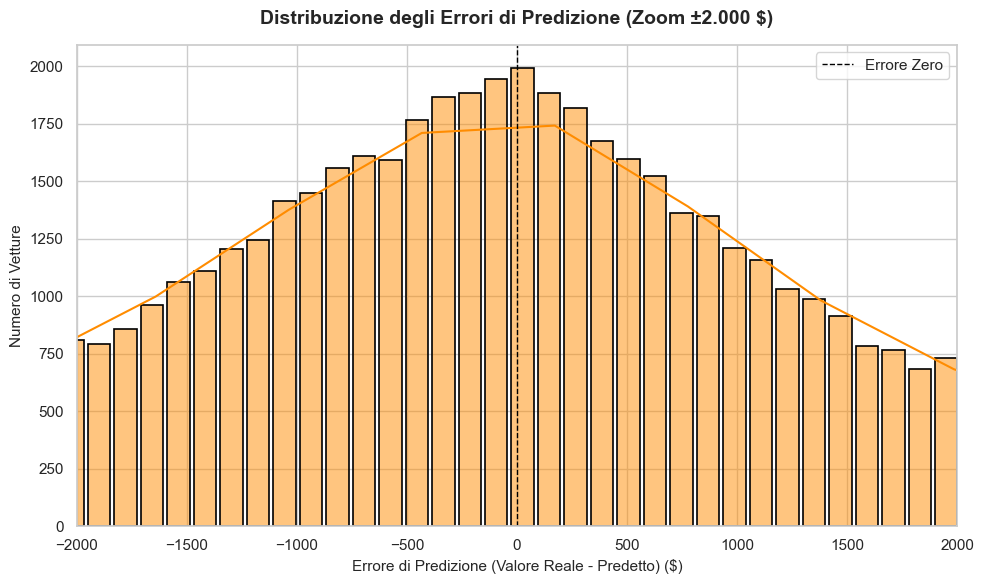

📊 ANALISI DI PRECISIONE NELLO ZOOM:
-> Il 64.1% delle auto nel test set viene predetto con un errore inferiore a 2000 $.
MARCHE CON L'ERRORE MEDIO (MAE) PIÙ ALTO ED INCIDENZA SUL TOTALE:
       marca auto_sbagliate auto_totali percentuale_errate mae_marca errore_percentuale_medio
17541.468085             12          12             100.0% 6119.66 $                    56.5%
27541.353583            303         310              97.7% 5366.95 $                    19.0%
29050.433696            223         230              97.0% 4706.81 $                    15.6%
13195.023256             22          22             100.0% 4209.02 $                    33.8%
30926.409514          2,856       2,950              96.8% 3312.98 $                    10.9%
24843.206178          2,736       2,858              95.7% 3075.46 $                    12.4%
20933.159255          1,802       1,878              96.0% 2912.80 $                    13.9%
20073.150918         11,545      11,985              96.3% 28

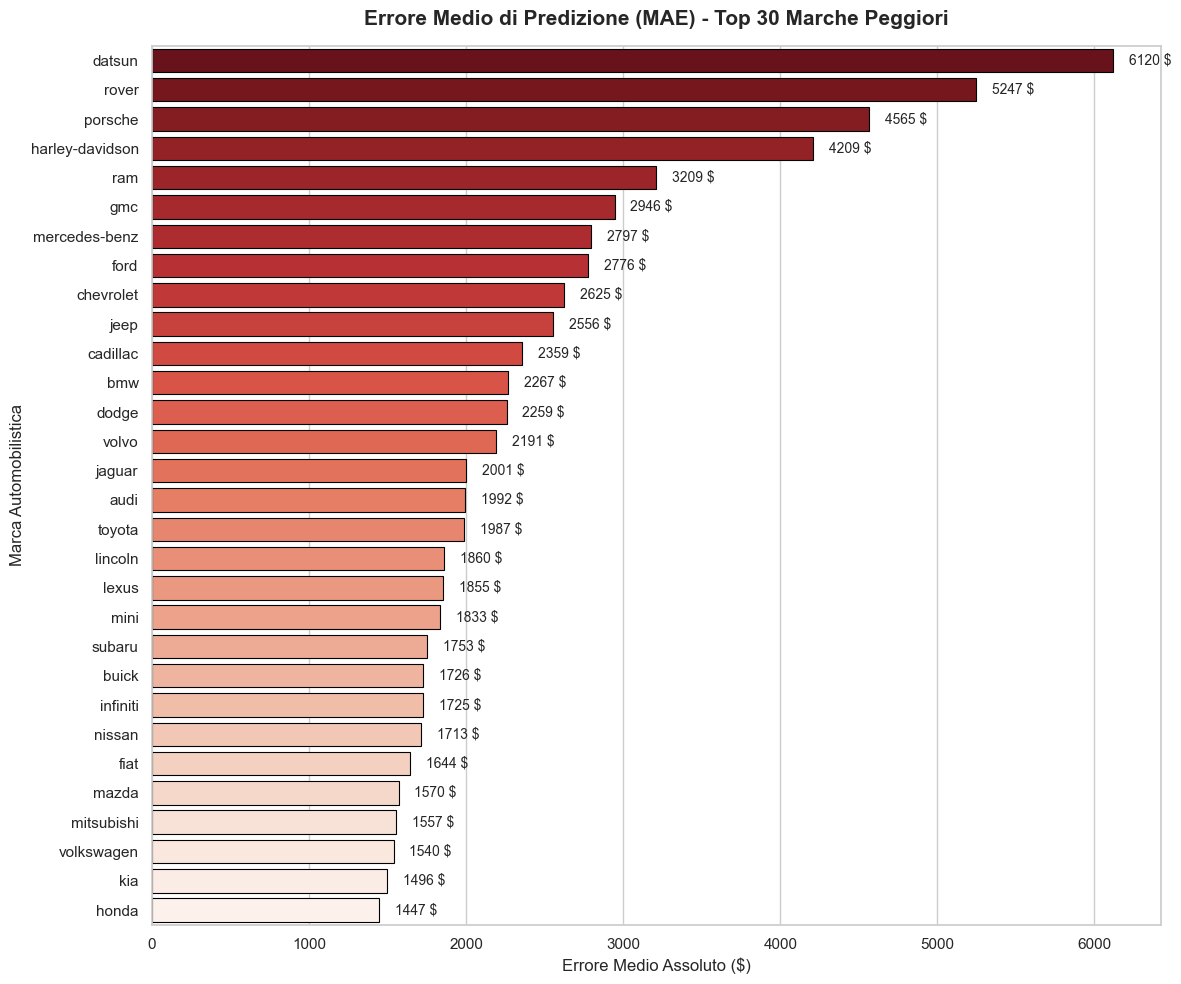

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# ISTOGRAMMA DEI RESIDUI ZOOMATO (TRA -2000$ E +2000$)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.histplot(
    residui, 
    kde=True, 
    color='darkorange', 
    bins=1000,           
    shrink=0.85,
    edgecolor='black',  
    linewidth=1.2       
)

# Applichiamo il limite richiesto sull'asse delle X
plt.xlim(-2000, 2000)

# 4. Linea nera di riferimento sullo ZERO (il punto di predizione perfetta)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Errore Zero')

# Personalizzazione estetica
plt.title("Distribuzione degli Errori di Predizione (Zoom ±2.000 $)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Errore di Predizione (Valore Reale - Predetto) ($)", fontsize=11)
plt.ylabel("Numero di Vetture", fontsize=11)
plt.legend()

plt.tight_layout()
plt.show()

# =========================================================================
# CALCOLO DELLA PERCENTUALE DI ERRORI IN QUESTA FASCIA
# =========================================================================
# Giusto per darti un dato numerico da spendere nella relazione/analisi:
auto_nella_fascia = ((residui >= -2000) & (residui <= 2000)).sum()
percentuale = (auto_nella_fascia / len(residui)) * 100

print(f"📊 ANALISI DI PRECISIONE NELLO ZOOM:")
print(f"-> Il {percentuale:.1f}% delle auto nel test set viene predetto con un errore inferiore a 2000 $.")
print("=========================================================================")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Recuperiamo la colonna originale delle marche da X_wo_test prima del One-Hot Encoding.
colonne_make = [col for col in X_test.columns if col.startswith('make_')]

if colonne_make:
    # Trucco inverso: idxmax trova la colonna con il valore 1, poi togliamo il prefisso 'make_'
    marche_ricostruite = X_test[colonne_make].idxmax(axis=1).str.replace('make_', '')
else:
    # Se per caso hai ancora la colonna originale non codificata nel dataset
    marche_ricostruite = X_test['manufacturer']

# Creiamo il DataFrame contenente i reali, i predetti e gli errori
df_errori = pd.DataFrame({
    'marca': marche_ricostruite,
    'prezzo_reale': y_test,
    'prezzo_predetto': y_pred,
    'errore_assoluto': np.abs(y_test - y_pred)
})

# =========================================================================
# 2. AGGREGAZIONE E CALCOLO DELLE PERCENTUALI DI ERRORE PER MARCA
# =========================================================================
# 2a. Calcoliamo i volumi totali di auto nel test set per ogni marca
volumi_totali = df_errori.groupby('marca').size().to_frame('auto_totali')

# 2b. Applichiamo il filtro sulle auto con errore > 100$
df_errori_oltre_100 = df_errori[df_errori['errore_assoluto'] > 100]

# 2c. Aggreghiamo i dati delle sole auto deviate
analisi_marche = (
    df_errori_oltre_100.groupby('marca')
    .agg(
        auto_sbagliate=('errore_assoluto', 'count'),
        mae_marca=('errore_assoluto', 'mean'),
        prezzo_reale_medio=('prezzo_reale', 'mean')
    )
)

# 2d. Uniamo i volumi totali per calcolare la percentuale di errore sul totale
analisi_marche = volumi_totali.join(analisi_marche, how='left').fillna({'auto_sbagliate': 0, 'mae_marca': 0}).reset_index()

# Calcoliamo le percentuali richieste
analisi_marche['percentuale_errate'] = (analisi_marche['auto_sbagliate'] / analisi_marche['auto_totali']) * 100
analisi_marche['errore_percentuale_medio'] = (analisi_marche['mae_marca'] / analisi_marche['prezzo_reale_medio']) * 100

# Ordiniamo la classifica in base al MAE più alto
# Escludiamo eventuali marche con MAE a 0 per non sporcare il grafico/tabella
analisi_marche = analisi_marche[analisi_marche['mae_marca'] > 0]
analisi_marche = analisi_marche.sort_values(by='mae_marca', ascending=False).reset_index(drop=True)

print("=====================================================================================================")
print("MARCHE CON L'ERRORE MEDIO (MAE) PIÙ ALTO ED INCIDENZA SUL TOTALE:")
print("=====================================================================================================")
print(analisi_marche[['marca', 'auto_sbagliate', 'auto_totali', 'percentuale_errate', 'mae_marca', 'errore_percentuale_medio']].head(35).to_string(index=False, formatters={
    'auto_totali': '{:,.0f}'.format,
    'auto_sbagliate': '{:,.0f}'.format,
    'percentuale_errate': '{:.1f}%'.format,
    'mae_marca': '{:.2f} $'.format,
    'errore_percentuale_medio': '{:.1f}%'.format
}))
print("=====================================================================================================")


# =========================================================================
# 3. GRAFICO DEL MAE PER OGNI MARCA (DOVE SBAGLIA DI PIÙ?)
# =========================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. RICOSTRUZIONE DELLE MARCHE ORIGINALI
# =========================================================================
# Il modo più semplice e sicuro per recuperare i nomi in formato testo 
# è rileggere la colonna direttamente dal CSV originale.
X_raw = pd.read_csv("X_wo_test.csv")

# Assumiamo che la colonna delle marche si chiami 'manufacturer' (o 'make')
colonna_marca = 'manufacturer' if 'manufacturer' in X_raw.columns else 'make'
marche_originali = X_raw[colonna_marca]

# Creiamo il DataFrame contenente i reali, i predetti e gli errori assoluti
df_errori = pd.DataFrame({
    'marca': marche_originali,
    'prezzo_reale': y_test,
    'prezzo_predetto': y_pred,
    'errore_assoluto': np.abs(residui) # residui era stato calcolato precedentemente
})

# =========================================================================
# 2. AGGREGAZIONE E CALCOLO DELLE METRICHE PER MARCA
# =========================================================================
# Calcoliamo il MAE reale considerando TUTTE le auto di una determinata marca
analisi_marche = df_errori.groupby('marca').agg(
    auto_totali=('marca', 'count'),
    mae_marca=('errore_assoluto', 'mean'),
    prezzo_reale_medio=('prezzo_reale', 'mean')
).reset_index()

# Calcoliamo le auto con errore grave (es. > 100$) per mantenere la tua logica
errori_gravi = df_errori[df_errori['errore_assoluto'] > 100].groupby('marca').size().to_frame('auto_sbagliate_piu_100')
analisi_marche = analisi_marche.merge(errori_gravi, on='marca', how='left').fillna({'auto_sbagliate_piu_100': 0})

# Calcolo percentuali
analisi_marche['percentuale_errate_piu_100'] = (analisi_marche['auto_sbagliate_piu_100'] / analisi_marche['auto_totali']) * 100
analisi_marche['errore_percentuale_medio'] = (analisi_marche['mae_marca'] / analisi_marche['prezzo_reale_medio']) * 100

# FILTRO: escludiamo marche con troppo poche auto (es. meno di 5) 
# per evitare che 1 solo errore grave sballi l'intera classifica
analisi_marche = analisi_marche[analisi_marche['auto_totali'] >= 5]

# Ordiniamo la classifica in base al MAE peggiore
analisi_marche = analisi_marche.sort_values(by='mae_marca', ascending=False).reset_index(drop=True)

print("=====================================================================================================")
print("MARCHE CON L'ERRORE MEDIO (MAE) PIÙ ALTO (Filtrate per min. 5 auto):")
print("=====================================================================================================")
print(analisi_marche[['marca', 'auto_totali', 'auto_sbagliate_piu_100', 'percentuale_errate_piu_100', 'mae_marca', 'errore_percentuale_medio']].head(30).to_string(index=False, formatters={
    'auto_totali': '{:,.0f}'.format,
    'auto_sbagliate_piu_100': '{:,.0f}'.format,
    'percentuale_errate_piu_100': '{:.1f}%'.format,
    'mae_marca': '{:.2f} $'.format,
    'errore_percentuale_medio': '{:.1f}%'.format
}))
print("=====================================================================================================")

# =========================================================================
# 3. GRAFICO DEL MAE PER OGNI MARCA (DOVE SBAGLIA DI PIÙ?)
# =========================================================================
# Prendiamo solo le peggiori 30 marche per mantenere il grafico leggibile
dati_grafico = analisi_marche.head(30)

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='mae_marca',
    y='marca',
    data=dati_grafico,
    palette='Reds_r',
    hue='marca',
    legend=False,
    edgecolor='black',
    linewidth=0.8
)

plt.title("Errore Medio di Predizione (MAE) - Top 30 Marche Peggiori", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Errore Medio Assoluto ($)", fontsize=12)
plt.ylabel("Marca Automobilistica", fontsize=12)

# Aggiungiamo i valori numerici alla fine di ogni barra per maggiore chiarezza
for index, value in enumerate(dati_grafico['mae_marca']):
    plt.text(value + 100, index, f"{value:.0f} $", va='center', fontsize=10)

plt.tight_layout()

# Creiamo la cartella e salviamo
os.makedirs('grafici', exist_ok=True)
plt.savefig('grafici/mae_per_marca_LightGBM.png', dpi=300, bbox_inches="tight")

plt.show()